In [3]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor


In [5]:
import joblib

X_train = joblib.load("X_train_transformed_pre_assign.pkl")
X_test = joblib.load("X_test_transformed_pre_assign.pkl")

y_train = joblib.load("y_train_pre_assign.pkl")
y_test = joblib.load("y_test_pre_assign.pkl")

In [7]:


# -----------------------------
# 2. MÉTRICAS
# -----------------------------
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n===== {name} =====")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2  : {r2:.4f}")
    
    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# -----------------------------
# 3. MODELOS
# -----------------------------
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    )
}

models["XGBoost"] = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# 4. ENTRENAR Y EVALUAR
# -----------------------------
results = []

for name, model in models.items():
    res = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)

# -----------------------------
# 5. COMPARACIÓN
# -----------------------------
results_df = pd.DataFrame(results).sort_values("RMSE")

print("\n===== COMPARISON =====")
print(results_df)


===== LinearRegression =====
MAE : 10.90
RMSE: 14.03
R2  : 0.1788

===== RandomForest =====
MAE : 9.80
RMSE: 12.73
R2  : 0.3245

===== GradientBoosting =====
MAE : 9.80
RMSE: 12.73
R2  : 0.3248

===== XGBoost =====
MAE : 9.69
RMSE: 12.61
R2  : 0.3365

===== COMPARISON =====
              model        MAE       RMSE        R2
3           XGBoost   9.687238  12.614306  0.336519
2  GradientBoosting   9.799995  12.725430  0.324777
1      RandomForest   9.798981  12.728193  0.324484
0  LinearRegression  10.898965  14.033700  0.178805


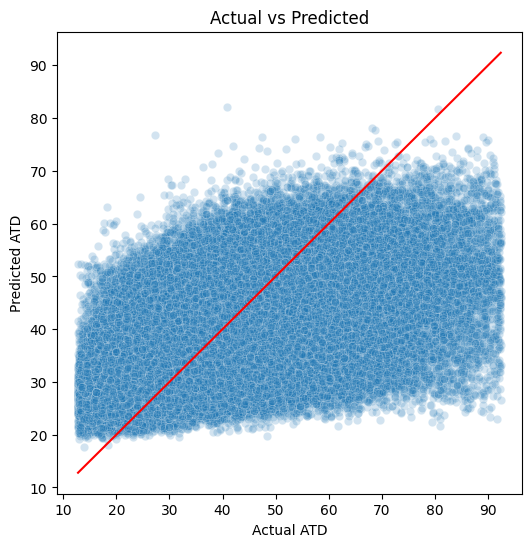

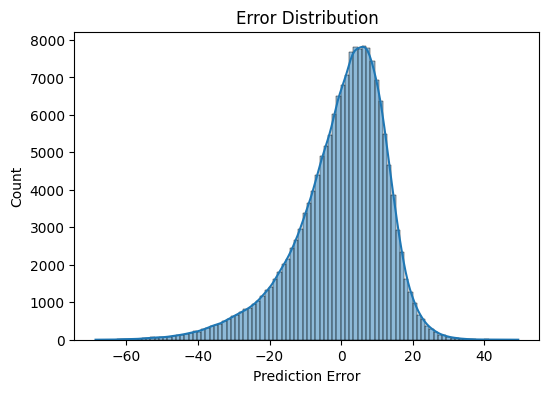

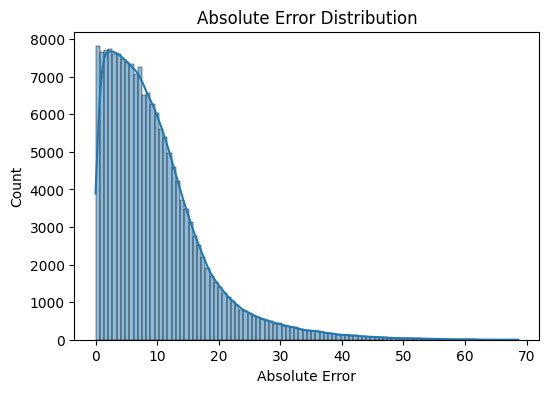

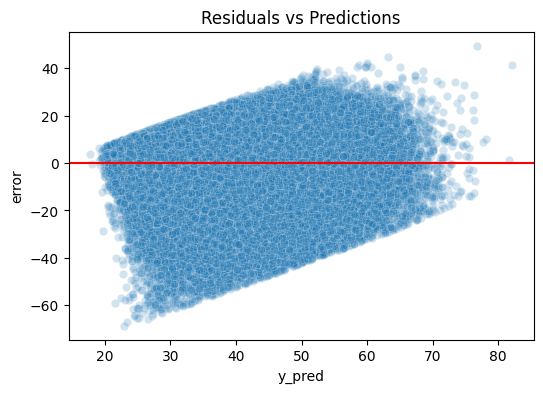

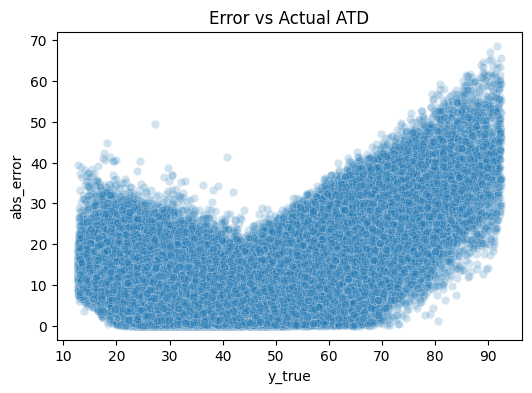

P50 error: 7.92 min
P90 error: 19.63 min

Error by ATD range:
bin
(12.799000000000001, 23.85]    10.957156
(23.85, 30.683]                 6.981002
(30.683, 38.2]                  5.933904
(38.2, 49.05]                   7.275701
(49.05, 92.383]                17.288008
Name: abs_error, dtype: float64


/var/folders/yd/tfd55g4x63d6mkkqlcscwgvr0000gn/T/ipykernel_60476/382051411.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = df_eval.groupby("bin")["abs_error"].mean()


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. USAR MEJOR MODELO
# -----------------------------
best_model = models["XGBoost"]  # o el que quieras

y_pred = best_model.predict(X_test)

# dataframe evaluación
df_eval = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
})

df_eval["error"] = df_eval["y_pred"] - df_eval["y_true"]
df_eval["abs_error"] = np.abs(df_eval["error"])

# -----------------------------
# 2. SCATTER: REAL vs PRED
# -----------------------------
plt.figure(figsize=(6,6))
sns.scatterplot(data=df_eval, x="y_true", y="y_pred", alpha=0.2)

# línea ideal
plt.plot(
    [df_eval["y_true"].min(), df_eval["y_true"].max()],
    [df_eval["y_true"].min(), df_eval["y_true"].max()],
    color="red"
)

plt.title("Actual vs Predicted")
plt.xlabel("Actual ATD")
plt.ylabel("Predicted ATD")
plt.show()

# -----------------------------
# 3. ERROR DISTRIBUTION
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df_eval["error"], bins=100, kde=True)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.show()

# -----------------------------
# 4. ABSOLUTE ERROR DISTRIBUTION
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df_eval["abs_error"], bins=100, kde=True)
plt.title("Absolute Error Distribution")
plt.xlabel("Absolute Error")
plt.show()

# -----------------------------
# 5. RESIDUALS vs PRED
# -----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_eval,
    x="y_pred",
    y="error",
    alpha=0.2
)
plt.axhline(0, color="red")
plt.title("Residuals vs Predictions")
plt.show()

# -----------------------------
# 6. ERROR vs REAL (MUY IMPORTANTE)
# -----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_eval,
    x="y_true",
    y="abs_error",
    alpha=0.2
)
plt.title("Error vs Actual ATD")
plt.show()

# -----------------------------
# 7. PERCENTILES (NEGOCIO)
# -----------------------------
p50 = np.percentile(df_eval["abs_error"], 50)
p90 = np.percentile(df_eval["abs_error"], 90)

print(f"P50 error: {p50:.2f} min")
print(f"P90 error: {p90:.2f} min")

# -----------------------------
# 8. ERROR POR RANGO
# -----------------------------
df_eval["bin"] = pd.qcut(df_eval["y_true"], 5)

error_by_bin = df_eval.groupby("bin")["abs_error"].mean()
print("\nError by ATD range:")
print(error_by_bin)

In [10]:
df_eval.sort_values(by='abs_error')

,y_true,y_pred,error,abs_error,bin
42559,34.266667,34.266880,0.000213,0.000213,"(30.683, 38.2]"
333968,29.316667,29.316439,-0.000228,0.000228,"(23.85, 30.683]"
663754,50.516667,50.516994,0.000328,0.000328,"(49.05, 92.383]"
36850,51.316667,51.316330,-0.000337,0.000337,"(49.05, 92.383]"
744675,37.033333,37.034016,0.000682,0.000682,"(30.683, 38.2]"
...,...,...,...,...,...
425780,90.133333,24.876225,-65.257109,65.257109,"(49.05, 92.383]"
613354,90.550000,25.235497,-65.314503,65.314503,"(49.05, 92.383]"
519380,92.383333,26.647703,-65.735630,65.735630,"(49.05, 92.383]"
307216,90.316667,23.323885,-66.992782,66.992782,"(49.05, 92.383]"


In [15]:
import joblib

joblib.dump(best_model, "best_model_pre_assign.pkl")

['best_model_pre_assign.pkl']

In [16]:
import joblib
import numpy as np

# cargar
X_train = joblib.load("X_train_transformed_post_assign.pkl")
X_test = joblib.load("X_test_transformed_post_assign.pkl")

y_train = joblib.load("y_train_post_assign.pkl")
y_test = joblib.load("y_test_post_assign.pkl")

# -----------------------------
# 1. FILTRAR NaNs EN X (filas completas)
# -----------------------------
train_mask = ~np.isnan(X_train).any(axis=1)
test_mask = ~np.isnan(X_test).any(axis=1)

# -----------------------------
# 2. APLICAR FILTRO A X e y
# -----------------------------
X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

# -----------------------------
# 3. VERIFICACIÓN
# -----------------------------
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (673931, 31)
Test shape: (168584, 31)


In [17]:
# -----------------------------
# 2. MÉTRICAS
# -----------------------------
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n===== {name} =====")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2  : {r2:.4f}")
    
    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# -----------------------------
# 3. MODELOS
# -----------------------------
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    )
}

models["XGBoost"] = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# 4. ENTRENAR Y EVALUAR
# -----------------------------
results = []

for name, model in models.items():
    res = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)

# -----------------------------
# 5. COMPARACIÓN
# -----------------------------
results_df = pd.DataFrame(results).sort_values("RMSE")

print("\n===== COMPARISON =====")
print(results_df)


===== LinearRegression =====
MAE : 10.69
RMSE: 13.77
R2  : 0.2109

===== RandomForest =====
MAE : 9.63
RMSE: 12.50
R2  : 0.3498

===== GradientBoosting =====
MAE : 9.62
RMSE: 12.47
R2  : 0.3520

===== XGBoost =====
MAE : 9.49
RMSE: 12.35
R2  : 0.3651

===== COMPARISON =====
              model        MAE       RMSE        R2
3           XGBoost   9.491069  12.347253  0.365096
2  GradientBoosting   9.616689  12.473674  0.352029
1      RandomForest   9.630453  12.495025  0.349808
0  LinearRegression  10.691771  13.765123  0.210909


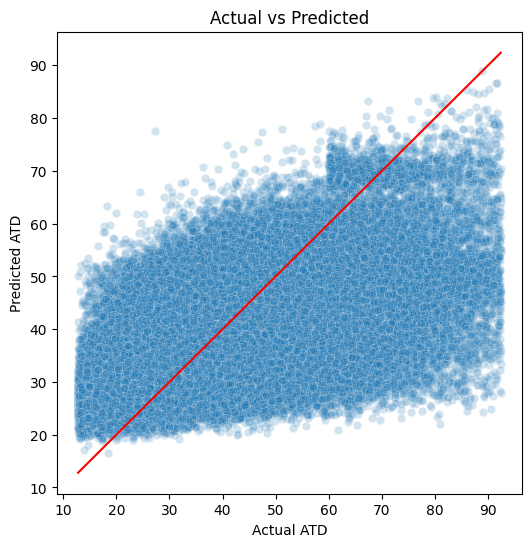

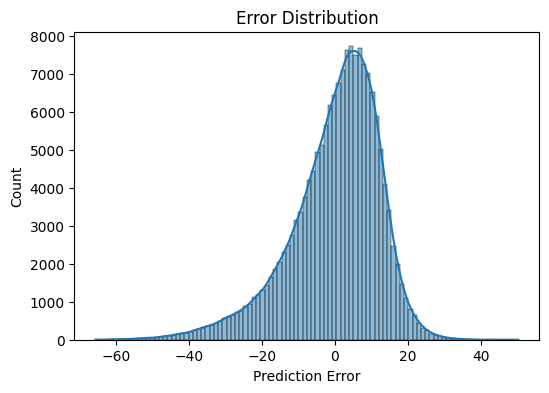

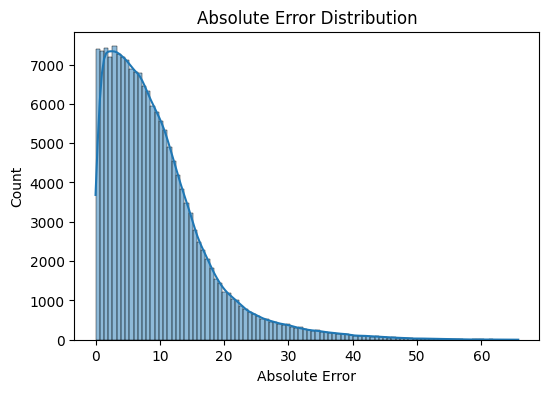

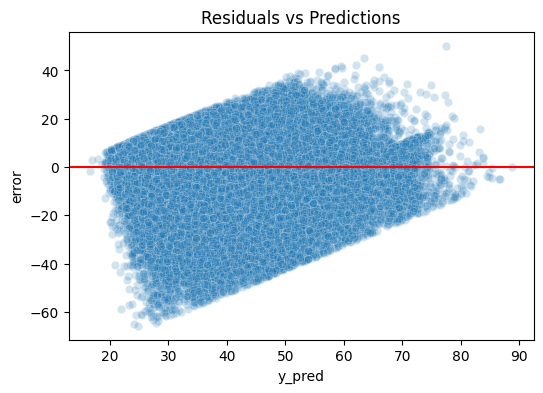

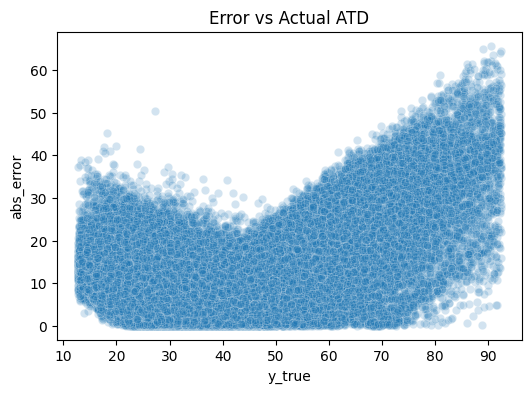

P50 error: 7.78 min
P90 error: 19.18 min

Error by ATD range:
bin
(12.799000000000001, 23.833]    10.793771
(23.833, 30.667]                 6.830443
(30.667, 38.183]                 5.836589
(38.183, 49.05]                  7.266464
(49.05, 92.383]                 16.731464
Name: abs_error, dtype: float64


/var/folders/yd/tfd55g4x63d6mkkqlcscwgvr0000gn/T/ipykernel_60476/382051411.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = df_eval.groupby("bin")["abs_error"].mean()


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. USAR MEJOR MODELO
# -----------------------------
best_model = models["XGBoost"]  # o el que quieras

y_pred = best_model.predict(X_test)

# dataframe evaluación
df_eval = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
})

df_eval["error"] = df_eval["y_pred"] - df_eval["y_true"]
df_eval["abs_error"] = np.abs(df_eval["error"])

# -----------------------------
# 2. SCATTER: REAL vs PRED
# -----------------------------
plt.figure(figsize=(6,6))
sns.scatterplot(data=df_eval, x="y_true", y="y_pred", alpha=0.2)

# línea ideal
plt.plot(
    [df_eval["y_true"].min(), df_eval["y_true"].max()],
    [df_eval["y_true"].min(), df_eval["y_true"].max()],
    color="red"
)

plt.title("Actual vs Predicted")
plt.xlabel("Actual ATD")
plt.ylabel("Predicted ATD")
plt.show()

# -----------------------------
# 3. ERROR DISTRIBUTION
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df_eval["error"], bins=100, kde=True)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.show()

# -----------------------------
# 4. ABSOLUTE ERROR DISTRIBUTION
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df_eval["abs_error"], bins=100, kde=True)
plt.title("Absolute Error Distribution")
plt.xlabel("Absolute Error")
plt.show()

# -----------------------------
# 5. RESIDUALS vs PRED
# -----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_eval,
    x="y_pred",
    y="error",
    alpha=0.2
)
plt.axhline(0, color="red")
plt.title("Residuals vs Predictions")
plt.show()

# -----------------------------
# 6. ERROR vs REAL (MUY IMPORTANTE)
# -----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_eval,
    x="y_true",
    y="abs_error",
    alpha=0.2
)
plt.title("Error vs Actual ATD")
plt.show()

# -----------------------------
# 7. PERCENTILES (NEGOCIO)
# -----------------------------
p50 = np.percentile(df_eval["abs_error"], 50)
p90 = np.percentile(df_eval["abs_error"], 90)

print(f"P50 error: {p50:.2f} min")
print(f"P90 error: {p90:.2f} min")

# -----------------------------
# 8. ERROR POR RANGO
# -----------------------------
df_eval["bin"] = pd.qcut(df_eval["y_true"], 5)

error_by_bin = df_eval.groupby("bin")["abs_error"].mean()
print("\nError by ATD range:")
print(error_by_bin)

In [19]:
import joblib

joblib.dump(best_model, "best_model_post_assign.pkl")

['best_model_post_assign.pkl']

In [20]:
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [24]:

pipeline = joblib.load("preprocessing_pipeline_post_assign.pkl")

pipeline

,steps,"[('preprocessing', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()

AttributeError: Estimator log does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?